In [1]:
import pandas as pd
import sys
import os

sys.path.append(os.path.abspath("../src"))

### Load dataset  

The dataset contains 25,000 labeled IMDB reviews.

Each review is labeled as positive (1) or negative (0).

We load the data and inspect basic statistics.

In [2]:
df = pd.read_csv('../data/labeledTrainData.tsv.zip', header=0, delimiter="\t", quoting=3)
df.describe()

,sentiment
count,25000.00000
mean,0.50000
std,0.50001
min,0.00000
25%,0.00000
50%,0.50000
75%,1.00000
max,1.00000


### Custom preprocessing utilities  

Import project‑specific pandas extensions (registered as .nlp) for text normalization and tokenization.

In [3]:
import my_utils # noqa: F401

wordlist = df.review.nlp.review_to_wordlist()
wordlist.shape

(25000,)

### Tokenization preview  

Convert raw HTML‑containing reviews into normalized word lists.

This helps verify that preprocessing behaves as expected.

In [4]:
wordlist[:10]

0    [stuff, going, moment, mj, started, listening,...
1    [classic, war, worlds, timothy, hines, enterta...
2    [film, starts, manager, nicholas, bell, giving...
3    [must, assumed, praised, film, greatest, filme...
4    [superbly, trashy, wondrously, unpretentious, ...
5    [dont, know, people, think, bad, movie, got, p...
6    [movie, could, good, comes, way, short, cheesy...
7    [watched, video, friend, house, glad, waste, m...
8    [friend, mine, bought, film, even, grossly, ov...
9    [movie, full, references, like, mad, max, ii, ...
Name: review, dtype: object

### TF‑IDF representation  

Convert the corpus into a sparse TF‑IDF matrix.

max_df=0.85 removes extremely common words.

English stopwords are removed automatically.

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english', max_df=0.85)
tfidf_matrix = vectorizer.fit_transform(df.review)
tfidf_matrix.shape

(25000, 74538)

### Latent semantic analysis (SVD)  

Reduce the high‑dimensional TF‑IDF space to 100 latent components.

This step captures the major semantic axes while keeping computation manageable.

In [6]:
from sklearn.decomposition import TruncatedSVD


svd = TruncatedSVD(n_components=100, random_state=42)
X_reduced = svd.fit_transform(tfidf_matrix)
X_reduced.shape

(25000, 100)

### PCA projection (2D)  

Project the SVD‑reduced vectors into 2D for visualization.

PCA preserves global variance structure, allowing us to inspect coarse sentiment separation.

In [7]:
from sklearn.decomposition import PCA


pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_reduced)

### PCA visualization  

The scatter plot shows the first two principal components colored by sentiment.

Although PCA captures only ~16% of variance, some separation between positive and negative reviews is visible.

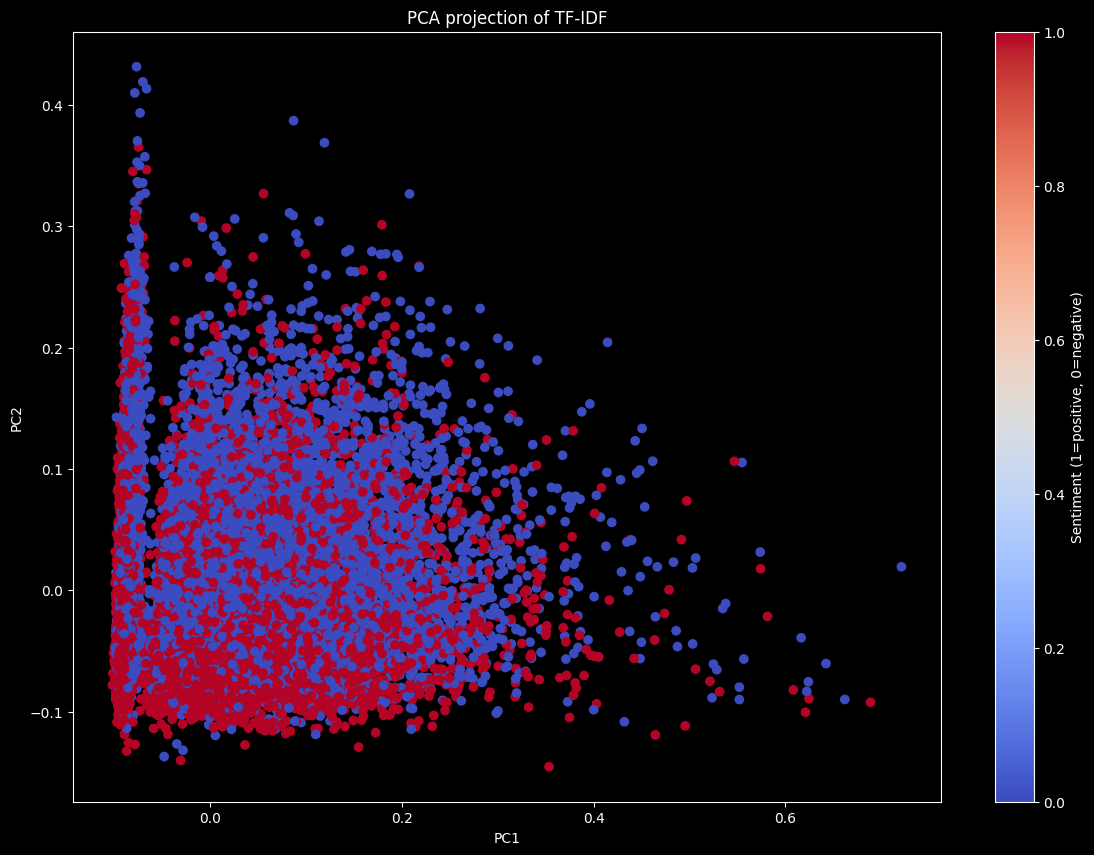

In [8]:
from matplotlib import pyplot as plt

# --- PCA Sentiment ---
plt.figure(figsize=(14, 10))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df.sentiment, cmap='coolwarm')
plt.title("PCA projection of TF-IDF")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Sentiment (1=positive, 0=negative)")
plt.show()

### Explained variance  

PCA(2) captures ~16% of the variance.

This is typical for sparse high‑dimensional text data, where variance is distributed across many components.

In [9]:
pca.explained_variance_ratio_.sum()

np.float64(0.1593281403843498)

### t‑SNE visualization  

t‑SNE focuses on preserving local neighborhoods rather than global variance.

It often reveals cluster structure that PCA cannot show.

In [10]:
from sklearn.manifold import TSNE


tsne = TSNE(n_components=2, perplexity=20, random_state=42)
X_tsne = tsne.fit_transform(X_reduced)

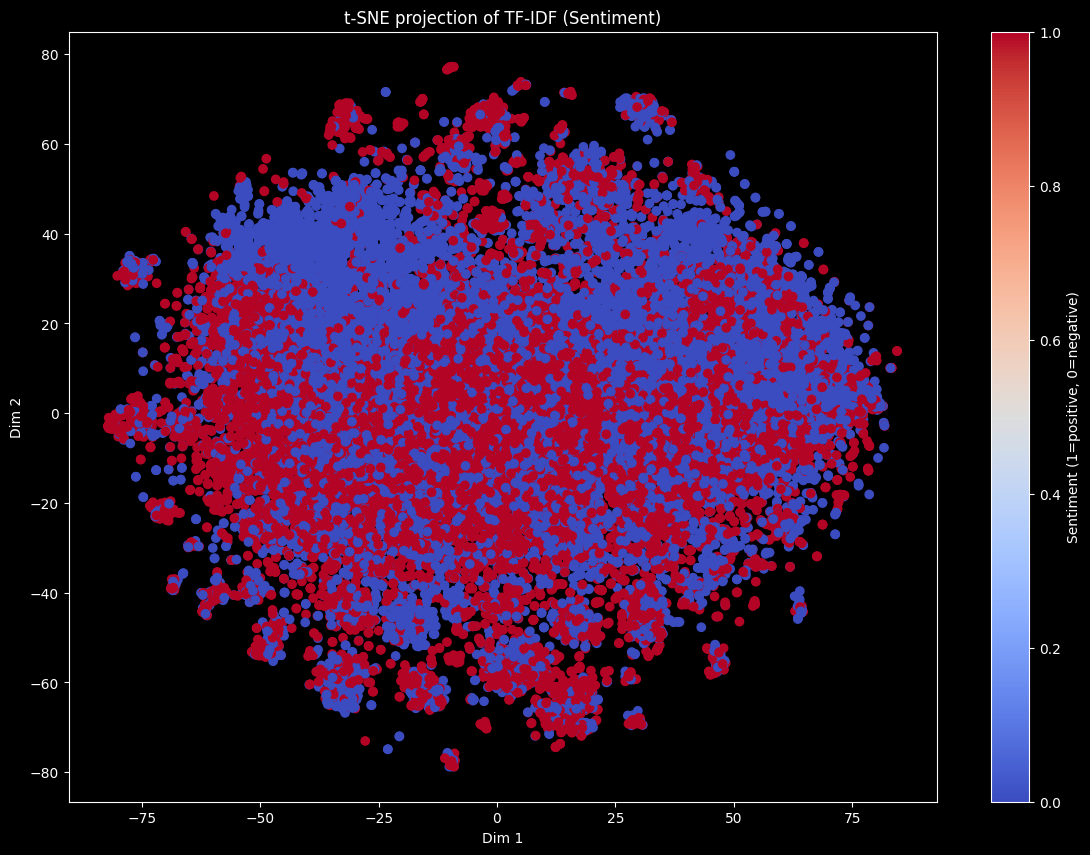

In [11]:
# --- t-SNE Sentiment ---
plt.figure(figsize=(14, 10))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=df.sentiment, cmap='coolwarm')
plt.title("t-SNE projection of TF-IDF (Sentiment)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.colorbar(label="Sentiment (1=positive, 0=negative)")
plt.show()


### Summary  

In this notebook, we explored the IMDB sentiment dataset, applied TF‑IDF vectorization, reduced dimensionality using SVD and PCA, and visualized the embeddings.
